## Import libraries

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor


# sklearn functions for evaluating regressors
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, max_error, root_mean_squared_error, PredictionErrorDisplay 

# dummy models for baseline
from sklearn.dummy import DummyRegressor


## Preparing the data

In [102]:
df = pd.read_parquet("DKHousingPrices.parquet", engine='fastparquet')

In [103]:
print(df["date"].min(), "to", df["date"].max())

1992-01-05 00:00:00 to 2024-10-26 00:00:00


In [104]:
#Drop all rows with na with na
df = df.dropna(subset=["city", "quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "area", "dk_ann_infl_rate%", "nom_interest_rate%", "yield_on_mortgage_credit_bonds%"])
df.head()

,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
1193,2024-09-30,218,1300,Apartment,regular_sale,1971,1765000,0.0,3,78.0,22628.205078,"Hedekæret 38, 1. th",2640,Hedehusene,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1194,2024-09-30,218,1307,Summerhouse,regular_sale,2009,590939,0.0,3,50.0,11818.780273,Violstien 11,2635,Ishøj,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1195,2024-09-30,218,1301,Apartment,regular_sale,1940,1750000,0.0,2,56.0,31250.000000,"Buddingevej 72I, st. tv",2800,Kongens Lyngby,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1196,2024-09-30,218,1302,Summerhouse,family_sale,1950,1080000,0.0,4,72.0,15000.000000,Frederiksvej 35,3730,Nexø,Bornholm,Bornholm,3.35,1.13,4.34
1197,2024-09-30,218,1303,Apartment,regular_sale,1974,2300000,0.0,1,50.0,46000.000000,"Thyrasgade 4, 4. 508",2200,København N,"Capital, Copenhagen",Zealand,3.35,1.13,4.34


#### Convert quarter from datetime to integer

In [105]:
#Convert a Period column to the number of days/months/years since a reference date
df["quarter"] = df["quarter"].astype("int64")
df["zip_code"] = df["zip_code"].astype("category")

### Make dummy variables

In [115]:
# We set drop_first=True to avoid the dummy variable trap
df = df.sample(frac=0.1, random_state=42).copy()
X = pd.get_dummies(df[["quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "zip_code", "area", "nom_interest_rate%", "dk_ann_infl_rate%", "yield_on_mortgage_credit_bonds%"]], drop_first=True)
y = df["purchase_price"]
X.head()

,quarter,year_build,no_rooms,sqm,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%,house_type_Farm,house_type_Summerhouse,house_type_Townhouse,...,zip_code_9981,zip_code_9982,zip_code_9990,"area_Capital, Copenhagen",area_East & mid jutland,area_Fyn & islands,area_North Zealand,area_North jutland,area_Other islands,area_South jutland
119928,213,1981,3,50.0,2.60,3.31,4.79,False,True,False,...,False,False,False,False,True,False,False,False,False,False
29153,217,1950,3,98.0,3.60,1.13,4.34,False,False,False,...,False,False,False,False,False,False,False,False,False,True
874457,169,1965,5,156.0,0.75,2.40,3.66,False,False,False,...,False,False,False,False,False,False,False,False,False,False
457394,199,1965,4,108.0,0.00,0.76,1.35,False,False,False,...,False,False,False,False,True,False,False,False,False,False
644826,190,1963,4,141.0,0.00,1.15,2.26,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## Feature importance testing

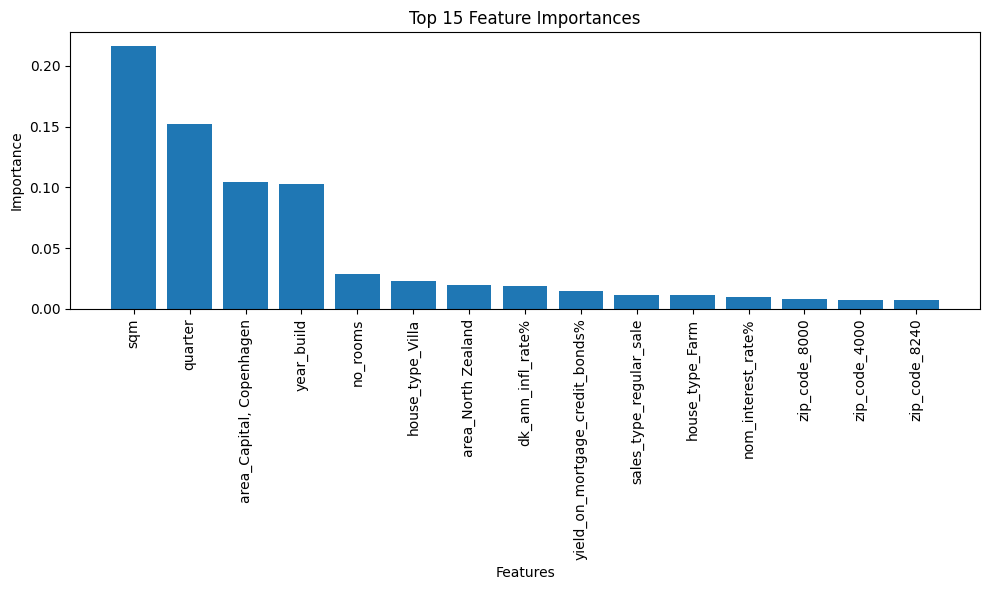

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Initialize a Random Forest classifier
clf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the classifier on the training data
clf.fit(X_train, y_train)

importances = clf.feature_importances_

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

top_15_features = indices[:15]
# Get the top 15 feature names and importances
top_15_names = [X.columns[i] for i in top_15_features]
top_15_importances = importances[top_15_features]

# Create plot for top 15 features
plt.figure(figsize=(10, 6))
plt.title("Top 15 Feature Importances")
plt.bar(range(15), top_15_importances)
plt.xticks(range(15), top_15_names, rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()

### Setting the variables based off the feature importance test

In [9]:
X = X[top_15_names]
y = df["purchase_price"]
X.shape, y.shape
X.head()

,sqm,quarter,"area_Capital, Copenhagen",year_build,no_rooms,house_type_Villa,area_North Zealand,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%,sales_type_regular_sale,house_type_Farm,nom_interest_rate%,zip_code_8000,zip_code_4000,zip_code_8240
465021,129.0,199,False,1974,5,True,True,0.76,1.35,True,False,0.00,False,False,False
742767,148.0,181,False,1968,6,True,False,0.45,2.78,True,False,0.00,False,False,False
1167754,128.0,139,False,2006,3,False,False,1.15,5.26,True,False,2.00,False,False,False
1051169,149.0,149,False,2003,5,True,False,1.69,5.70,True,False,3.75,False,False,False
412051,86.0,201,False,1968,4,False,False,0.42,1.10,True,False,0.00,False,False,False


### Training and test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Creating a baseline

This baselines is based on the mean value from the dataset

In [11]:
dm = DummyRegressor(strategy='mean')
dm.fit(X_train, y_train)

DummyRegressor()

In [12]:
dm_y_pred = dm.predict(X_test)

In [13]:
print("Score on training set: {:.3f}".format(dm.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(dm.score(X_test, y_test)))

Score on training set: 0.000
Score on test set: -0.000


## Linear Regression Model

Make the training and testing split

In [14]:
# Create and fit the model
lr = LinearRegression()
lr_y_pred = lr.fit(X_train, y_train).predict(X_test)

In [15]:
#Evaluate the model
print("Score on training set: {:.3f}".format(lr.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(lr.score(X_test, y_test)))

Score on training set: 0.334
Score on test set: 0.343


## Polynomial Regression Model

We use the code below to create polynomial features on the training data to the degree of 5. 

In [17]:
# Let's try with degree 2 instead of 3 to reduce memory usage
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)  # Only transform, don't fit again

In [18]:
# Create and fit the model
poly_lr = LinearRegression()
pr_y_pred = poly_lr.fit(X_train_poly,y_train).predict(X_test_poly)

Evaluating the model

In [19]:
print("Score on training set: {:.3f}".format(poly_lr.score(X_train_poly, y_train)))
print("Score on test set: {:.3f}".format(poly_lr.score(X_test_poly, y_test)))

Score on training set: 0.495
Score on test set: 0.479


## Grid Search CV

In [21]:
# Here we set up a grid search to find the best polynomial degree for our features.
# We define a parameter grid with degrees from 1 to 5.
param_grid = {
   'poly_features__degree': [1, 2, 3, 4, 5]
}

# create the pipeline with PolynomialFeatures and LinearRegression
model = Pipeline([
   ('poly_features', PolynomialFeatures()),
   ('lin_reg', LinearRegression())
])

# set up GridSearchCV with the model and parameter grid. r2 is used as the scoring metric, and n_jobs=-1 allows for parallel processing across all available CPU cores.
grid_search = GridSearchCV(model, param_grid, scoring='r2', n_jobs=-1)

# fit the grid search to the training data
grid_search.fit(X_train, y_train)

# retrieve and print the scores for each iteration
cv_results = grid_search.cv_results_
for mean_score, params in zip(cv_results["mean_test_score"], cv_results["params"]):
   print(f"Mean R-squared for {params}: {mean_score}")

# retrieve the best hyperparameters and the corresponding best estimator
best_degree = grid_search.best_params_['poly_features__degree']
best_model = grid_search.best_estimator_

# print the best hyperparameters
print(f"Best Polynomial Degree: {best_degree}")

# evaluate the best model on the test data
test_score = best_model.score(X_test, y_test)
print(f"Test R-squared with best model: {test_score}")

## KNN Model

Fitting a KNeighborsRegressor and defining it as knn.

In [22]:
knn = KNeighborsRegressor()
knn_y_pred = knn.fit(X_train, y_train).predict(X_test)

In [23]:
# print scores
print("Score on training set: {:.3f}".format(knn.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(knn.score(X_test, y_test)))

Score on training set: 0.423
Score on test set: 0.133


Using StandardScaler to standardize the scales of attributes.

In [24]:
scaler = StandardScaler() # define the scaler
X_train_scaled = scaler.fit_transform(X_train) # apply to the training feature matrix
X_test_scaled = scaler.transform(X_test) # apply to the testing feature matrix

Fitting a KNeighborsRegressor and defining it as knn_scaled.

In [25]:
knn_scaled = KNeighborsRegressor(n_neighbors=30, p=1, weights='distance')
knn_standard_y_pred = knn_scaled.fit(X_train_scaled, y_train).predict(X_test_scaled)

In [26]:
print("Score on training set: {:.3f}".format(knn_scaled.score(X_train_scaled, y_train)))
print("Score on test set: {:.3f}".format(knn_scaled.score(X_test_scaled, y_test)))

Score on training set: 0.999
Score on test set: 0.480


Applying RobustScaler.

In [27]:
robust_scaler = RobustScaler() # define the scaler
X_train_robust = robust_scaler.fit_transform(X_train) # apply to the training feature matrix
X_test_robust = robust_scaler.transform(X_test) # apply to the testing feature matrix

Fitting a KNeighborsRegressor and defining it as knn_robust.

In [28]:
knn_robust = KNeighborsRegressor(n_neighbors=48, p=2, weights='distance')
knn_robust_y_pred = knn_robust.fit(X_train_robust, y_train).predict(X_test_robust)

In [29]:
print("Score on training set: {:.3f}".format(knn_robust.score(X_train_robust, y_train)))
print("Score on test set: {:.3f}".format(knn_robust.score(X_test_robust, y_test)))

Score on training set: 0.999
Score on test set: 0.462


Setting up a parameter grid.

In [ ]:
param_grid = {
   'n_neighbors': [1, 5, 10, 20, 30], # what should we set k to 
   'weights': ['uniform', 'distance'], # uniform weighting vs. distance weighting
   'p': [1, 2], # 1 for manhattan vs. 2 for euclidean distance
}

Using GridSearchCV.

In [32]:
grid_search = GridSearchCV(estimator=knn_robust,  # the model being tuned
                          param_grid=param_grid,  # dictionary of parameter values to search over
                          cv=5,  # number of folds to use
                          scoring='r2',  # evaluation metric
                          return_train_score=True,  # whether to return training scores in the output.
                          verbose=3)  # controls the verbosity of the output (i.e., how much output to print)

# fit the model with training data X_train_robust and target y_train
grid_search.fit(X_train_robust, y_train)  

In [33]:
print("Best hyperparameter settings found: ", grid_search.best_params_)

In [34]:
best_knn = grid_search.best_estimator_
print("Score on training set: {:.3f}".format(best_knn.score(X_train_robust, y_train)))
print("Score on test set: {:.3f}".format(best_knn.score(X_test_robust, y_test)))

Using GridSearchCV with scaling.

In [35]:
# define the pipeline with a placeholder scaler and the KNN regressor
pipe = Pipeline([
   ('scaler', StandardScaler()),  # Placeholder scaler
   ('knn', KNeighborsRegressor())
])

# define the parameter grid to include different scalers and KNN parameters
param_grid = {
   'scaler': [StandardScaler()],  # different scaling methods (`passthrough` means no scaling)
   'knn__n_neighbors': [3, 6, 12, 24, 48, 96],
   'knn__weights': ['distance'],
   'knn__p': [2],
}

# set up GridSearchCV with the pipeline and parameter grid
grid_search = GridSearchCV(
   estimator=pipe,
   param_grid=param_grid,
   scoring='r2',
   return_train_score=True,
   verbose=3
)

#fit the model with the original training data (without prior scaling)
grid_search.fit(X_train, y_train)

In [36]:
print("Best hyperparameter settings found: ", grid_search.best_params_)

## Random Forest Regressor

In [37]:

rf = RandomForestRegressor(
    n_estimators=150,        
    max_depth=20,          
    min_samples_leaf=5,      
    max_features="sqrt",     
    n_jobs=-1,
    random_state=42,
)

In [38]:
# Fit the model to the training data
rf_y_pred = rf.fit(X_train, y_train).predict(X_test)

In [39]:
print("Score on training set: {:.3f}".format(rf.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(rf.score(X_test, y_test)))

Score on training set: 0.608
Score on test set: 0.495


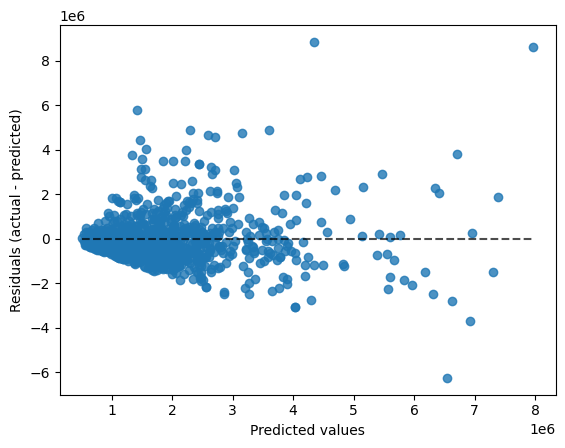

In [119]:
display = PredictionErrorDisplay.from_predictions(y_test, rf_y_pred)

## Evaluation
This will be done based on MAE, MAPE, MSE, RMSE and Max

In [40]:
# this is a function that takes actual y values (y_true) and predicted y values (y_pred) and calculates MAE, MAPE, MSE, and RMSE
def get_metrics(y_true, y_pred):
    
    # MAE: the average of the absolute differences between the actual values and the predicted values
    mae = mean_absolute_error(y_true, y_pred)
    
    # MAPE: the average absolute percentage difference between the actual and predicted values
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # MSE: the average of the squared differences between the actual values and the predicted values
    mse = mean_squared_error(y_true, y_pred)
    
    # RMSE: the square root of MSE
    rmse = root_mean_squared_error(y_true, y_pred)

    # Max error: the average absolute percentage difference between the actual and predicted values
    max = max_error(y_true, y_pred)
    
    # return all four metrics
    return mae, mape, mse, rmse, max

In [41]:
# calculate the metrics for each model using our `get_metrics` function.
dm_metrics = get_metrics(y_test, dm_y_pred)  # for dummy regressor
lr_metrics = get_metrics(y_test, lr_y_pred)  # for linear regression
pr_metrics = get_metrics(y_test, pr_y_pred)  # for polynomial regression
kn_metrics = get_metrics(y_test, knn_y_pred)  # for KNN regressor
kn_standard_metrics = get_metrics(y_test, knn_standard_y_pred)  # for KNN regressor with standard scaling
kn_robust_metrics = get_metrics(y_test, knn_robust_y_pred)  # for KNN regressor with robust scaling
rf_metrics = get_metrics(y_test, rf_y_pred)  # for random forest regressor

In [42]:
# create a dataframe (table) to store and display the computed metrics where each row represents a different model and each column represents a different metric
results = pd.DataFrame({
    'Model': ['Dummy', 'Linear Regression', 'Polynomial Regression', 'KNN', 'KNN_standardscaler', 'KNN_robustscaler', 'Random Forest'],  # model names
    'MAE': [dm_metrics[0], lr_metrics[0], pr_metrics[0], kn_metrics[0], kn_standard_metrics[0], kn_robust_metrics[0], rf_metrics[0]],  # MAE values for each model
    'MAPE': [dm_metrics[1], lr_metrics[1], pr_metrics[1], kn_metrics[1], kn_standard_metrics[1], kn_robust_metrics[1], rf_metrics[1]],  # MAPE values for each model
    'MSE': [dm_metrics[2], lr_metrics[2], pr_metrics[2], kn_metrics[2], kn_standard_metrics[2], kn_robust_metrics[2], rf_metrics[2]],  # MSE values for each model
    'RMSE': [dm_metrics[3], lr_metrics[3], pr_metrics[3], kn_metrics[3], kn_standard_metrics[3], kn_robust_metrics[3], rf_metrics[3]], # RMSE values for each model
    'Max': [dm_metrics[4], lr_metrics[4], pr_metrics[4], kn_metrics[4], kn_standard_metrics[4], kn_robust_metrics[4], rf_metrics[4]] # Max error values for each model
})

# display results
results

,Model,MAE,MAPE,MSE,RMSE,Max
0,Dummy,1.187342e+06,1.097294,3.186839e+12,1.785172e+06,3.058376e+07
1,Linear Regression,9.179024e+05,0.738023,2.094882e+12,1.447371e+06,2.599970e+07
2,Polynomial Regression,7.942936e+05,0.634216,1.659446e+12,1.288195e+06,2.466674e+07
3,KNN,1.034250e+06,0.814168,2.761207e+12,1.661688e+06,2.939149e+07
4,KNN_standardscaler,7.424725e+05,0.578710,1.655993e+12,1.286854e+06,2.709186e+07
5,KNN_robustscaler,7.481596e+05,0.582585,1.715231e+12,1.309668e+06,2.818005e+07
6,Random Forest,7.476871e+05,0.600075,1.608478e+12,1.268258e+06,2.768532e+07


**RANDOM FOREST TEST PREDICTION**

In [43]:
# Random Forest – detailed error analysis

rf_results = pd.DataFrame({
    "actual_price": y_test.values,
    "predicted_price": rf_y_pred
})

rf_results["abs_error"] = (
    rf_results["predicted_price"] - rf_results["actual_price"]
).abs()

rf_results["pct_error"] = (
    (rf_results["predicted_price"] - rf_results["actual_price"])
    / rf_results["actual_price"]
) * 100

rf_results["abs_pct_error"] = rf_results["pct_error"].abs()

In [44]:
print("\nError summary (Random Forest):")
print(
    rf_results[["abs_error", "abs_pct_error"]]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
)

thresholds = [5, 10, 15, 20, 25, 50]
for t in thresholds:
    share = (rf_results["abs_pct_error"] <= t).mean() * 100
    print(f"Within ±{t}%: {share:.1f}%")


Error summary (Random Forest):
          abs_error  abs_pct_error
count  3.766800e+04   37668.000000
mean   7.476871e+05      60.007514
std    1.024436e+06      86.353990
min    1.728034e+01       0.001616
50%    4.820214e+05      32.737650
75%    9.065478e+05      67.890139
90%    1.572920e+06     144.477841
95%    2.252052e+06     216.052276
99%    4.688906e+06     400.668056
max    2.768532e+07    2986.110640
Within ±5%: 8.8%
Within ±10%: 17.2%
Within ±15%: 25.6%
Within ±20%: 33.3%
Within ±25%: 40.4%
Within ±50%: 65.5%


In [79]:
case_idx = X_test.sample(1).index[0]

X_case = X_test.loc[[case_idx]]
actual = y_test.loc[case_idx]
pred   = rf.predict(X_case)[0]

print("\nSingle house prediction (Random Forest):")
print(f"Actual:    {actual:,.0f} kr.")
print(f"Predicted: {pred:,.0f} kr.")
print(f"Error:     {pred-actual:,.0f} kr. ({(pred-actual)/actual*100:.2f}%)")


Single house prediction (Random Forest):
Actual:    1,800,000 kr.
Predicted: 2,373,678 kr.
Error:     573,678 kr. (31.87%)


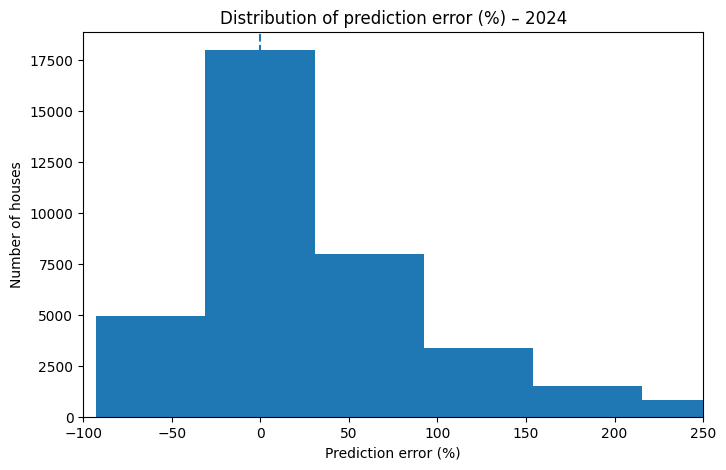

In [82]:
plt.figure(figsize=(8,5))
plt.hist(rf_results["pct_error"], bins=50)

plt.axvline(0, linestyle="--")
plt.xlim(-100, 250)
plt.xlabel("Prediction error (%)")
plt.ylabel("Number of houses")
plt.title("Distribution of prediction error (%) – 2024")
plt.show()